**Autor:** Andrés Alejandro Rodríguez Lozano  
**Portafolio:** Portafolio de Andrés Alejandro Rodríguez Lozano

# Capítulo 3 — Retornos anuales y mensuales

$$R_Y = \prod_{t \in Y}(1+R_t)-1$$


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = ['svg']
plt.rcParams.update({
    'figure.dpi': 72,
    'savefig.dpi': 72,
    'figure.figsize': (8, 3.8),
    'font.size': 9,
    'svg.fonttype': 'none',
    'path.simplify': True,
    'path.simplify_threshold': 0.2,
})

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))
import portfolio_utils as pu

def load_monthly():
    """Carga precios mensuales: cache mensual, diario, o yfinance."""
    mpath = ROOT / 'data' / 'precios_mensuales.csv'
    if mpath.exists():
        print('Precios mensuales (cache):', mpath.name)
        return pd.read_csv(mpath, index_col=0, parse_dates=True).loc[: '2026-09-30']
    csv = ROOT / 'data' / 'precios_ajustados_diarios.csv'
    if csv.exists():
        daily = pd.read_csv(csv, index_col=0, parse_dates=True)
        print('Precios diarios (cache):', csv.name)
        return pu.to_month_end(daily).loc[: '2026-09-30']
    tickers = sorted(set(list(pu.CURRENT_WEIGHTS) + [pu.BENCHMARK]))
    print('Descargando precios con yfinance…')
    daily = pu.download_prices(tickers)
    return pu.to_month_end(daily).loc[: '2026-09-30']


monthly = load_monthly()
bt = pu.backtest_portfolio(monthly, pu.CURRENT_WEIGHTS, start='2016-01-31', end='2026-09-30', rebalance='A')
spy = pu.backtest_portfolio(monthly, {'SPY': 1}, start='2016-01-31', end='2026-09-30', rebalance='N')
ann_p = (1 + bt['return']).groupby(bt.index.year).prod() - 1
ann_s = (1 + spy['return']).groupby(spy.index.year).prod() - 1
tabla = pd.DataFrame({'Portafolio': ann_p, 'SPY': ann_s, 'Activo': ann_p - ann_s})
print(tabla.map(lambda x: f'{100*x:.2f}%'))


Precios mensuales (cache): precios_mensuales.csv
     Portafolio      SPY  Activo
date                            
2016     17.59%   12.00%   5.59%
2017     30.15%   21.71%   8.44%
2018     -4.78%   -4.57%  -0.21%
2019     31.46%   31.22%   0.23%
2020     27.89%   18.33%   9.56%
2021     26.56%   28.73%  -2.17%
2022    -21.02%  -18.18%  -2.85%
2023     32.47%   26.18%   6.30%
2024     28.03%   24.89%   3.15%
2025     27.45%   17.72%   9.73%
2026     24.94%   12.71%  12.23%


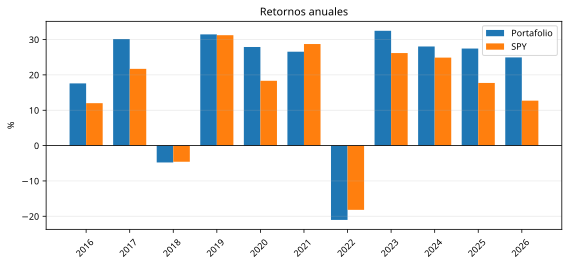

In [2]:
# Barras anuales — matplotlib
years = tabla.index.tolist()
x = np.arange(len(years))
w = 0.38
fig, ax = plt.subplots()
ax.bar(x - w/2, tabla['Portafolio'] * 100, w, label='Portafolio')
ax.bar(x + w/2, tabla['SPY'] * 100, w, label='SPY')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(years, rotation=45)
ax.set_ylabel('%')
ax.set_title('Retornos anuales')
ax.legend()
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


## Conclusiones
1. Alpha concentrado en años risk-on; 2022 es el año crítico.

## Ejercicios
1. Peor trimestre.
2. % años con activo > 0.
